In [8]:
import pandas as pd
from evaluation import match, classify_by_thresh


def evaluation(
    lang: str, feature_cols: list[str], weights: list[float], threshold: float
):
    df = pd.read_csv(f"../benchmark/ground_truth/{lang}_ground_truth.csv")
    phantom_pairs = pd.read_csv(
        f"../benchmark/ground_truth/{lang}_validation_results.csv"
    )
    phantom_pairs = phantom_pairs[~phantom_pairs["validation"]][
        ["record_id", "old_index", "new_index"]
    ]
    df["score"] = sum(
        df[feature_cols[i]] * weights[i] for i in range(len(feature_cols))
    )
    df["index_sim"] = abs(df["old_index"] - df["new_index"])
    matched_df = match(df)
    final_res = classify_by_thresh(matched_df, threshold, phantom_pairs)
    final_res.to_excel(
        f"../benchmark/evaluation/{lang}_evaluation_results.xlsx", index=False
    )
    num_records = final_res["record_id"].nunique()
    num_mappings = len(final_res[final_res["label"] == 1])
    num_preds = len(final_res[final_res["pred"] == 1])
    num_TP = len(final_res[(final_res["label"] == 1) & (final_res["pred"] == 1)])
    num_FP = len(final_res[(final_res["label"] == 0) & (final_res["pred"] == 1)])
    num_FN = len(final_res[(final_res["label"] == 1) & (final_res["pred"] == 0)])
    precision = num_TP / num_preds
    recall = num_TP / num_mappings
    F1 = 2 * precision * recall / (precision + recall)
    return [
        num_records,
        num_mappings,
        num_preds,
        num_TP,
        num_FP,
        num_FN,
        precision * 100,
        recall * 100,
        F1 * 100,
    ]


java_res = evaluation(
    "java", ["class_sim", "method_sim", "arg_sim"], [1 / 3, 1 / 3, 1 / 3], 0.45
)
py_res = evaluation("py", ["fqn_sim", "arg_sim"], [1 / 2, 1 / 2], 0.35)
pd.DataFrame(
    [["Java"] + java_res, ["Python"] + py_res],
    columns=[
        "Language",
        "Records",
        "GT",
        "Predicted",
        "TP",
        "FP",
        "FN",
        "Precision",
        "Recall",
        "F1 score",
    ],
)

,Language,Records,GT,Predicted,TP,FP,FN,Precision,Recall,F1 score
0,Java,638,344,333,305,28,39,91.591592,88.662791,90.103397
1,Python,609,242,172,155,17,87,90.116279,64.049587,74.879227


In [9]:
import pandas as pd


def fp_analysis():
    for lang in ["java", "py"]:
        phantom_pairs = pd.read_csv(
            f"../benchmark/ground_truth/{lang}_validation_results.csv"
        )
        df = pd.read_excel(f"../benchmark/evaluation/{lang}_evaluation_results.xlsx")
        fp = df[(df["label"] == 0) & (df["pred"] == 1)][
            ["record_id", "old_index", "new_index"]
        ].merge(phantom_pairs)
        num_removal = len(fp[fp["old_removal"]])
        num_depre = len(fp[fp["old_deprecated"]])
        num_fp = len(fp)
        print(f"{lang}: {num_fp} false positives")
        print(f"    removal: {num_removal} ({num_removal/num_fp*100:.1f}%)")
        print(f"    deprecated: {num_depre} ({num_depre/num_fp*100:.1f}%)")


fp_analysis()

java: 28 false positives
    removal: 24 (85.7%)
    deprecated: 4 (14.3%)
py: 17 false positives
    removal: 4 (23.5%)
    deprecated: 13 (76.5%)


In [10]:
def fn_analysis():
    thresh = {"java": 0.45, "py": 0.35}
    for lang in ["java", "py"]:
        validation = pd.read_csv(
            f"../benchmark/ground_truth/{lang}_validation_results.csv"
        )
        df = pd.read_excel(f"../benchmark/evaluation/{lang}_evaluation_results.xlsx")
        fn = df[(df["label"] == 1) & (df["pred"] == 0)].merge(validation)
        num_fn = len(fn)
        print(f"{lang}: {num_fn} false negatives")
        num_low_sim = len(fn[fn["score"] <= thresh[lang]])
        print(f"    low similarity: {num_low_sim} ({num_low_sim/num_fn*100:.1f}%)")
        fn_phase4 = fn[fn["score"] > thresh[lang]]
        num_non_exist = len(
            fn_phase4[~(fn_phase4["old_existence"] & fn_phase4["new_existence"])]
        )
        print(f"    API not exist: {num_non_exist} ({num_non_exist/num_fn*100:.1f}%)")
        num_no_depre = len(
            fn_phase4[fn_phase4["old_existence"] & fn_phase4["new_existence"]]
        )
        print(f"    No deprecation: {num_no_depre} ({num_no_depre/num_fn*100:.1f}%)")


fn_analysis()

java: 39 false negatives
    low similarity: 16 (41.0%)
    API not exist: 22 (56.4%)
    No deprecation: 1 (2.6%)
py: 87 false negatives
    low similarity: 22 (25.3%)
    API not exist: 51 (58.6%)
    No deprecation: 14 (16.1%)


In [11]:
import pandas as pd
from pymongo import MongoClient

client = MongoClient("127.0.0.1", 27017)
db = client["bridge"]


def col2df(lang: str):
    data = []
    col = db[f"{lang}_candidate_update_instances"]
    for doc in col.find(projection={"_id": 0}):
        res = [doc["commit"], doc["library"]]

        version_before = doc["version_before"]
        version_after = doc["version_after"]
        old_api = doc["old_callee"]["full_name"]
        new_api = doc["new_callee"]["full_name"]
        if lang == "java":
            old_api = f"{old_api}({','.join(doc['most_prob_old_param_types'])})"
            new_api = f"{new_api}({','.join(doc['most_prob_new_param_types'])})"
        parts1 = [int(_) for _ in version_before.split(".")]
        parts2 = [int(_) for _ in version_after.split(".")]
        if parts1 > parts2:
            res.extend(
                [
                    version_after,
                    version_before,
                    True,
                    new_api,
                    old_api,
                    doc["new_existence"],
                    doc["old_existence"],
                ]
            )
        else:
            res.extend(
                [
                    version_before,
                    version_after,
                    False,
                    old_api,
                    new_api,
                    doc["old_existence"],
                    doc["new_existence"],
                ]
            )

        res.extend([doc["old_removal"], doc["old_deprecated"], doc["validation"]])
        data.append(res)
    df = pd.DataFrame(
        data,
        columns=[
            "commit",
            "library",
            "old_version",
            "new_version",
            "downgrade",
            "old_api",
            "new_api",
            "old_existence",
            "new_existence",
            "old_removal",
            "old_deprecated",
            "validation",
        ],
    )
    df.to_csv(f"../benchmark/final/{lang}_dataset_metadata.csv", index=False)
    return df


dfs = {"java": col2df("java"), "python": col2df("py")}

In [12]:
def scale_analysis():
    data = []
    for lang, df in dfs.items():
        df = df[df["validation"]]
        num_instances = len(df)
        num_commits = df["commit"].nunique()
        num_libs = df["library"].nunique()
        num_lib_versions = pd.concat(
            [
                df["library"] + " " + df["old_version"],
                df["library"] + " " + df["new_version"],
            ]
        ).nunique()
        num_version_updates = len(
            df.drop_duplicates(subset=["library", "old_version", "new_version"])
        )
        num_mappings = len(df.drop_duplicates(subset=["library", "old_api", "new_api"]))
        num_pairs = len(
            df.drop_duplicates(
                subset=["library", "old_version", "new_version", "old_api", "new_api"]
            )
        )
        data.append(
            [
                lang,
                num_libs,
                num_lib_versions,
                num_version_updates,
                num_mappings,
                num_pairs,
                num_instances,
                num_commits,
            ]
        )
    return pd.DataFrame(
        data,
        columns=[
            "Language",
            "Libraries",
            "Releases",
            "Version Transitions",
            "Mappings",
            "Pairs",
            "Instances",
            "Commits",
        ],
    )


scale_analysis()

,Language,Libraries,Releases,Version Transitions,Mappings,Pairs,Instances,Commits
0,java,2557,12165,10637,18900,35532,381661,17266
1,python,999,4908,5190,4456,11393,277259,7850


In [13]:
def mine_process():
    for lang, df in dfs.items():
        num_candidate = len(df)
        num_final = len(df[df["validation"]])
        print(f"{lang}: {num_candidate} candidate API update instances")
        non_existence = len(df[~(df["old_existence"] & df["new_existence"])])
        print(f"    {non_existence} API signature resolution failures")
        non_deprecate = num_candidate - num_final - non_existence
        print(f"    {non_deprecate} no deprecation or removal evidences")
        print(f"    {num_final} validated API update instances")
        num_rmv_path = len(df[df["validation"] & df["old_removal"]])
        print(f"    {num_rmv_path} passes API removal path")
        num_deprec_path = num_final - num_rmv_path
        print(f"    {num_deprec_path} passes API deprecation path")


mine_process()

java: 686608 candidate API update instances
    238403 API signature resolution failures
    66544 no deprecation or removal evidences
    381661 validated API update instances
    111925 passes API removal path
    269736 passes API deprecation path
python: 561018 candidate API update instances
    85926 API signature resolution failures
    197833 no deprecation or removal evidences
    277259 validated API update instances
    228840 passes API removal path
    48419 passes API deprecation path


In [14]:
import pandas as pd

dfs = {
    "java": pd.read_csv(
        "../benchmark/final/java_dataset_metadata.csv",
        low_memory=False,
        keep_default_na=False,
    ),
    "python": pd.read_csv(
        "../benchmark/final/py_dataset_metadata.csv",
        low_memory=False,
        keep_default_na=False,
    ),
}

In [15]:
def summarize_data(df: pd.DataFrame):
    df = df[df["validation"]]
    cmt_per_lib = (
        df.groupby("library")["commit"]
        .nunique()
        .reset_index()
        .sort_values("commit", ascending=False)
    )
    instance_per_lib = df["library"].value_counts().reset_index()
    mapping_per_lib = (
        df[["library", "old_api", "new_api"]]
        .drop_duplicates()["library"]
        .value_counts()
        .reset_index()
    )
    instance_per_mapping = (
        df.groupby(["library", "old_api", "new_api"])
        .size()
        .reset_index(name="instance")
        .sort_values("instance", ascending=False)
    )
    cmt_per_mapping = (
        df.groupby(["library", "old_api", "new_api"])["commit"]
        .nunique()
        .reset_index()
        .sort_values("commit", ascending=False)
    )
    mapping_per_update = (
        df[["library", "commit", "old_version", "new_version", "old_api", "new_api"]]
        .drop_duplicates()
        .groupby(["library", "commit", "old_version", "new_version"])
        .size()
        .reset_index(name="mapping")
        .sort_values("mapping", ascending=False)
    )

    return {
        "instance_per_lib": instance_per_lib,
        "cmt_per_lib": cmt_per_lib,
        "mapping_per_lib": mapping_per_lib,
        "instance_per_mapping": instance_per_mapping,
        "cmt_per_mapping": cmt_per_mapping,
        "mapping_per_update": mapping_per_update,
    }


java_summary = summarize_data(dfs["java"])
python_summary = summarize_data(dfs["python"])

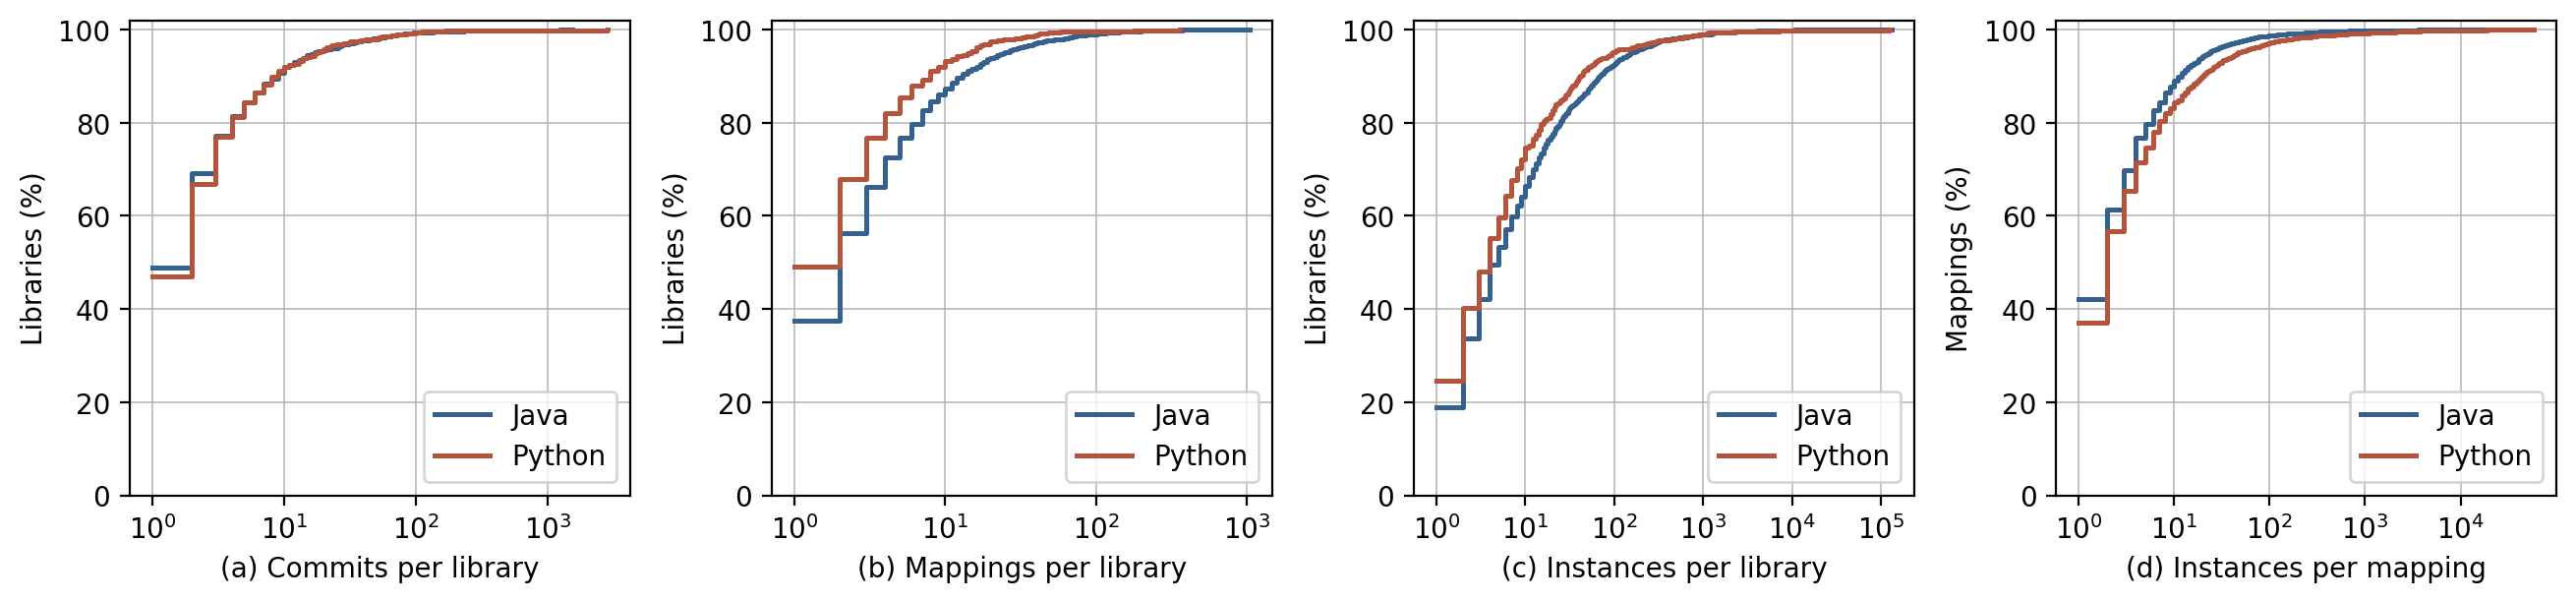

In [16]:
%matplotlib inline
%config InlineBackend.figure_formats="retina"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter, LogLocator

# plt.rcParams.update(
#     {
#         "font.family": "serif",
#         "font.size": 10,
#         "axes.labelsize": 10,
#         "xtick.labelsize": 9,
#         "ytick.labelsize": 9,
#         "legend.fontsize": 9,
#         "pdf.fonttype": 42,
#         "ps.fonttype": 42,
#     }
# )


def compute_cdf(frequencies: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    values = frequencies.dropna().to_numpy()
    values = values[values > 0]

    x, counts = np.unique(values, return_counts=True)
    cdf = np.cumsum(counts) / counts.sum()
    return x, cdf


def plot_cdf(
    summary_data: dict[str, dict[str, pd.Series]],
    labels: dict[str, tuple[str, str]],
    output_path: str | None = None,
) -> None:
    styles = {
        "Java": {"color": "#35618F", "marker": "o"},
        "Python": {"color": "#B5543D", "marker": "s"},
    }

    fig, axs = plt.subplots(1, len(labels), figsize=(3.3 * len(labels), 3.2))

    for ax, (k, label) in zip(axs, labels.items()):
        max_pow = 0
        for language, summary in summary_data.items():
            x, cdf = compute_cdf(summary[k].iloc[:, -1])
            style = styles[language]
            ax.step(
                x,
                cdf,
                where="post",
                label=language,
                color=style["color"],
                linewidth=1.8,
            )
            while 10**max_pow < x[-1]:
                max_pow += 1

        ax.set_xscale("log")
        ax.set_ylim(0, 1.02)
        ax.set_xticks([10**i for i in range(max_pow)])
        ax.minorticks_off()
        # # ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, symbol=None))
        ax.set_xlabel(label[0])
        ax.set_ylabel(label[1])
        ax.grid(True, color="#B0B0B0", linewidth=0.7, alpha=0.75)
        # ax.spines[["top", "right"]].set_visible(False)
        ax.legend(loc="lower right")

    fig.tight_layout()

    if output_path:
        fig.savefig(output_path, bbox_inches="tight")

    plt.show()


labels = {
    "cmt_per_lib": ("(a) Commits per library", "Libraries (%)"),
    "mapping_per_lib": ("(b) Mappings per library", "Libraries (%)"),
    "instance_per_lib": ("(c) Instances per library", "Libraries (%)"),
    "instance_per_mapping": ("(d) Instances per mapping", "Mappings (%)"),
    # "cmt_per_mapping": ("The number of commits", "The percentage of mappings"),
    # "mapping_per_update": ("The number of mappings", "The percentage of updates")
}

plot_cdf(
    {"Java": java_summary, "Python": python_summary},
    labels,
    output_path="../submission/figures/rq1_dataset_characteristics.pdf",
)

In [17]:
def cmt_by_lib_analysis(summary_data: dict[str, dict[str, pd.Series]]):
    for language, summary in summary_data.items():
        print(f"{language}:")
        frequencies = summary["cmt_per_lib"].iloc[:, -1]
        x, _ = compute_cdf(frequencies)
        print(f"    median: {np.median(frequencies)} commits")
        print(
            f"    {(frequencies == 1).mean()*100:.1f}% libraries appear in one commit"
        )
        print(
            f"    {(frequencies <= 10).mean()*100:.1f}% libraries appear in at most ten commits"
        )
        print(f"    maxima: {summary['cmt_per_lib'].iloc[0, 0]} in {x[-1]} commits")


cmt_by_lib_analysis({"Java": java_summary, "Python": python_summary})

Java:
    median: 2.0 commits
    49.0% libraries appear in one commit
    91.9% libraries appear in at most ten commits
    maxima: org.mockito:mockito-core in 1549 commits
Python:
    median: 2.0 commits
    46.9% libraries appear in one commit
    91.9% libraries appear in at most ten commits
    maxima: django in 2867 commits


In [18]:
def mapping_per_lib_analysis(summary_data: dict[str, dict[str, pd.Series]]):
    for language, summary in summary_data.items():
        print(f"{language}:")
        frequencies = summary["mapping_per_lib"].iloc[:, -1]
        x, _ = compute_cdf(frequencies)
        print(f"    median: {np.median(frequencies)} mappings")
        q1 = np.quantile(frequencies, 0.25)
        print(f"    1/4 quantile: {q1} mappings")
        q2 = np.quantile(frequencies, 0.75)
        print(f"    3/4 quantile: {q2} mappings")
        print(f"    {(frequencies == 1).mean()*100:.1f}% libraries have one mapping")
        print(
            f"    {(frequencies <= 10).mean()*100:.1f}% libraries have at most ten mappings"
        )
        print(
            f"    maxima: {summary['mapping_per_lib'].iloc[0, 0]} has {x[-1]} mappings"
        )


mapping_per_lib_analysis({"Java": java_summary, "Python": python_summary})

Java:
    median: 2.0 mappings
    1/4 quantile: 1.0 mappings
    3/4 quantile: 5.0 mappings
    37.5% libraries have one mapping
    87.4% libraries have at most ten mappings
    maxima: org.elasticsearch:elasticsearch has 1048 mappings
Python:
    median: 2.0 mappings
    1/4 quantile: 1.0 mappings
    3/4 quantile: 3.0 mappings
    49.1% libraries have one mapping
    93.2% libraries have at most ten mappings
    maxima: tensorflow has 361 mappings


In [19]:
def instance_per_lib_analysis(summary_data: dict[str, dict[str, pd.Series]]):
    for language, summary in summary_data.items():
        print(f"{language}:")
        frequencies = summary["instance_per_lib"].iloc[:, -1]
        x, _ = compute_cdf(frequencies)
        print(f"    median: {np.median(frequencies)} instances")
        q1 = np.quantile(frequencies, 0.25)
        print(f"    1/4 quantile: {q1} instances")
        q2 = np.quantile(frequencies, 0.75)
        print(f"    3/4 quantile: {q2} instances")
        print(f"    {(frequencies == 1).mean()*100:.1f}% libraries have one instance")
        print(
            f"    {(frequencies <= 100).mean()*100:.1f}% libraries have at most 100 instances"
        )
        print(
            f"    maxima: {summary['instance_per_lib'].iloc[0, 0]} has {x[-1]} instances"
        )


instance_per_lib_analysis({"Java": java_summary, "Python": python_summary})

Java:
    median: 5.0 instances
    1/4 quantile: 2.0 instances
    3/4 quantile: 17.0 instances
    19.0% libraries have one instance
    92.6% libraries have at most 100 instances
    maxima: junit:junit has 132630 instances
Python:
    median: 4.0 instances
    1/4 quantile: 2.0 instances
    3/4 quantile: 11.0 instances
    24.6% libraries have one instance
    95.1% libraries have at most 100 instances
    maxima: wagtail has 124226 instances


In [20]:
def instance_per_mapping_analysis(summary_data: dict[str, dict[str, pd.Series]]):
    for language, summary in summary_data.items():
        print(f"{language}:")
        frequencies = summary["instance_per_mapping"].iloc[:, -1]
        x, _ = compute_cdf(frequencies)
        print(f"    median: {np.median(frequencies)} instances")
        q1 = np.quantile(frequencies, 0.25)
        print(f"    1/4 quantile: {q1} instances")
        q2 = np.quantile(frequencies, 0.75)
        print(f"    3/4 quantile: {q2} instances")
        print(f"    {(frequencies == 1).mean()*100:.1f}% mappings have one instance")
        print(
            f"    {(frequencies <= 10).mean()*100:.1f}% mappings have at most 10 instances"
        )
        print(
            f"    maxima: {summary['instance_per_mapping'].iloc[0, 0]} has {x[-1]} instances"
        )


instance_per_mapping_analysis({"Java": java_summary, "Python": python_summary})

Java:
    median: 2.0 instances
    1/4 quantile: 1.0 instances
    3/4 quantile: 4.0 instances
    42.1% mappings have one instance
    89.0% mappings have at most 10 instances
    maxima: junit:junit has 33678 instances
Python:
    median: 2.0 instances
    1/4 quantile: 1.0 instances
    3/4 quantile: 6.0 instances
    37.1% mappings have one instance
    84.4% mappings have at most 10 instances
    maxima: django has 58780 instances
